# Merges pMHC fold specificity and AF2 ipSAE scores for all 110 designs and produces a ranked summary table.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# Set pandas to display all columns
pd.set_option('display.max_columns', None)
# To also see all rows (optional)
pd.set_option('display.max_rows', None)

In [2]:
PMHC_PATH   = "/n/groups/marks/users/aaron/pmhc_cp/specificity/pMHC_fold/outputs/r3/analysis/pmhc_fold_specificity_scores.tsv"
AF2_PATH    = "/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_ipae_ipsae_scores.csv"
OUT_DIR     = "/n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r3"
os.makedirs(OUT_DIR, exist_ok=True)

PEPTIDE_SEQ = "VVGADGVGK"  # p1-p9, D at p5
# Upward-facing positions (1-indexed in peptide): p5=D, p7=V, p9=K
# In the 8-row MPNN output (p4=A skipped), these are rows 4, 6, 8 (1-indexed within group)
# Confirmed by: V(p1) V(p2) G(p3) [A(p4) skipped] D(p5) G(p6) V(p7) G(p8) K(p9)
# So cumcount within group: 1=V(p1), 2=V(p2), 3=G(p3), 4=D(p5), 5=G(p6), 6=V(p7), 7=G(p8), 8=K(p9)
UPWARD_WT_AAS = {'D', 'V', 'K'}  # p5, p7, p9

In [3]:
# ── 1. Load AF2 ipSAE scores ──────────────────────────────────────────────────
print("Loading AF2 ipSAE scores...")
af2_df = pd.read_csv(AF2_PATH)
af2_df = af2_df.rename(columns={'label': 'design'})
af2_cols = ['design', 'ipsae_binder_peptide', 'pae_interaction', 'plddt_binder',
            'plddt_target', 'binder_aligned_rmsd', 'target_aligned_rmsd',
            'mean_pae_bp', 'n_contacts']
af2_df = af2_df[af2_cols].copy()
af2_df = af2_df[af2_df['ipsae_binder_peptide'] >= 0.8]
print(f"  {len(af2_df)} rows")

# ── 2. Load pMHC fold specificity scores ─────────────────────────────────────
print("Loading pMHC fold specificity scores...")
pmhc_df = pd.read_csv(PMHC_PATH, sep='\t')
pmhc_df = pmhc_df.rename(columns={'base_name': 'design'})
pmhc_cols = [
    'design',
    'ppi_pae_int_peptide_on', 'ppi_pae_int_peptide_off',
    'delta_pae_int_peptide',
    'plddt_peptide_on', 'plddt_peptide_off',
    'ppi_pae_int_on', 'ppi_pae_int_off',
    'delta_pae_int'
]
pmhc_df = pmhc_df[pmhc_cols].copy()
print(f"  {len(pmhc_df)} rows")

# ── 3. Merge all scores ───────────────────────────────────────────────────────
print("\nMerging all score tables...")

merged = af2_df.copy()
merged = merged.merge(pmhc_df,  on='design', how='left')

print(f"  Final merged table: {len(merged)} designs")
print(f"  Missing pMHC:  {merged['delta_pae_int_peptide'].isna().sum()}")

Loading AF2 ipSAE scores...
  205 rows
Loading pMHC fold specificity scores...
  205 rows

Merging all score tables...
  Final merged table: 205 designs
  Missing pMHC:  0


In [4]:
# ── 4. Compute per-metric ranks ───────────────────────────────────────────────
# For each metric, rank such that rank 1 = best design

# ipSAE: higher = better
merged['rank_ipsae'] = merged['ipsae_binder_peptide'].rank(ascending=False)

# pMHC fold Δ pAE_int_peptide: more negative = better
merged['rank_pmhc_spec'] = merged['delta_pae_int_peptide'].rank(ascending=True)

# pMHC fold on-target pAE_int_peptide: lower = better
merged['rank_pmhc_on'] = merged['ppi_pae_int_peptide_on'].rank(ascending=True)

# # ── 5. Combined rank ──────────────────────────────────────────────────────────
# # Primary filters already applied (ipSAE >= 0.8) — all 199 pass
# # Combine ranks with equal weighting across the three specificity metrics:
# #   pMHC fold Δ pAE, CMS p5, MPNN Δ p5
# # Plus ipSAE as a quality anchor
# merged['rank_combined'] = (
#     merged['rank_ipsae'] +
#     merged['rank_cms_p5'] +
#     merged['rank_pmhc_spec'] +
#     merged['rank_mpnn_p5']
# ) / 4

# merged = merged.sort_values('rank_combined')

# ── 6. Save ───────────────────────────────────────────────────────────────────
out_path = os.path.join(OUT_DIR, 'merged_scores_ranked.tsv')
merged.to_csv(out_path, sep='\t', index=False)
print(f"\nSaved merged ranked table to {out_path}")

# ── 7. Summary table (top 30) ─────────────────────────────────────────────────
summary_cols = [
    'design',
    'ipsae_binder_peptide',
    'pae_interaction',
    'plddt_binder',
    'delta_pae_int_peptide',
    'ppi_pae_int_peptide_on',
    'ppi_pae_int_peptide_off',
    'rank_ipsae',
    'rank_pmhc_spec',
#     'rank_combined',
]


Saved merged ranked table to /n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r3/merged_scores_ranked.tsv


In [5]:
# ── 8. Correlation between metrics ──────────────────────────────────────────
print("\n── Spearman correlations between specificity metrics ──")
spec_cols = [
    'ipsae_binder_peptide',
    'delta_pae_int_peptide',
    'ppi_pae_int_peptide_on',
]
# Friendlier axis labels
labels = [
    'ipSAE\n(binder-peptide)',
    'Δ pAE_int_peptide\n(pMHC fold spec.)',
    'pAE_int_peptide\n(on-target)',
]
corr = merged[spec_cols].corr(method='spearman').round(3)
print(corr.to_string())

corr_path = os.path.join(OUT_DIR, 'metric_correlations.tsv')
corr.to_csv(corr_path, sep='\t')
print(f"Correlation matrix saved to {corr_path}")

print("\nDone.")


── Spearman correlations between specificity metrics ──
                        ipsae_binder_peptide  delta_pae_int_peptide  ppi_pae_int_peptide_on
ipsae_binder_peptide                   1.000                  0.059                  -0.027
delta_pae_int_peptide                  0.059                  1.000                   0.334
ppi_pae_int_peptide_on                -0.027                  0.334                   1.000
Correlation matrix saved to /n/groups/marks/users/aaron/pmhc_cp/specificity/analysis/r3/metric_correlations.tsv

Done.


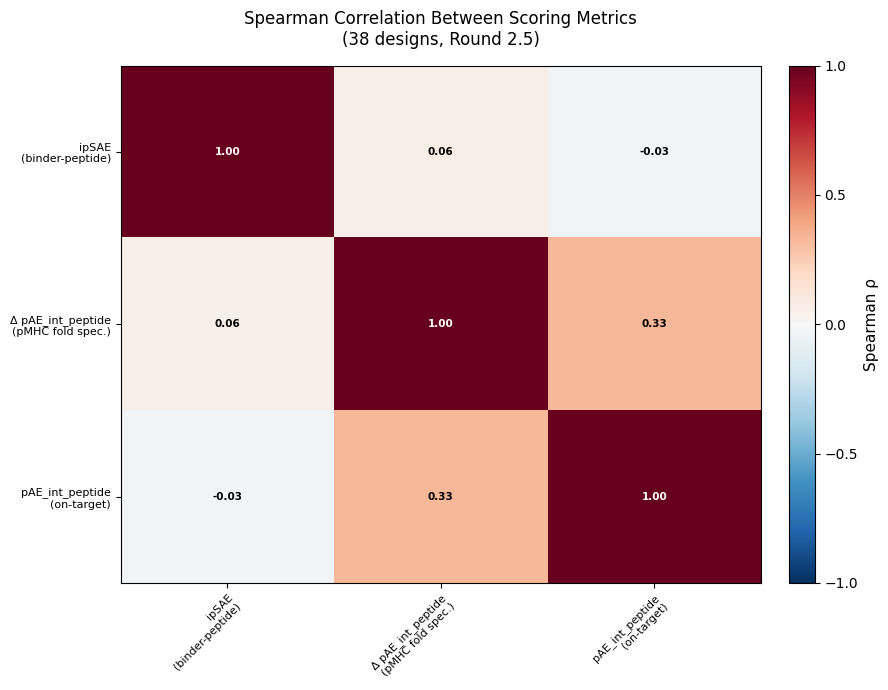

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# Tick labels
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right', rotation_mode='anchor')
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells with correlation values
for i in range(len(spec_cols)):
    for j in range(len(spec_cols)):
        val = corr.values[i, j]
        # Use white text on dark cells, black on light cells
        text_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=text_color, fontweight='bold')

ax.set_title('Spearman Correlation Between Scoring Metrics\n(38 designs, Round 2.5)',
             fontsize=12, pad=15)

plt.tight_layout()
plt.show()
# fig.savefig(f"{OUT_DIR}/metric_correlation_heatmap.png", dpi=150, bbox_inches='tight')
# print(f"Saved to {OUT_DIR}/metric_correlation_heatmap.png")
# plt.close()

In [7]:
print(len(merged[merged['delta_pae_int_peptide']<-0.5]))
merged[merged['delta_pae_int_peptide']<-0.5].sort_values('delta_pae_int_peptide', ascending=True)

80


,design,ipsae_binder_peptide,pae_interaction,plddt_binder,plddt_target,binder_aligned_rmsd,target_aligned_rmsd,mean_pae_bp,n_contacts,ppi_pae_int_peptide_on,ppi_pae_int_peptide_off,delta_pae_int_peptide,plddt_peptide_on,plddt_peptide_off,ppi_pae_int_on,ppi_pae_int_off,delta_pae_int,rank_ipsae,rank_pmhc_spec,rank_pmhc_on
125,orient_255_pt12__33_pt12__7_a9_t0.1_s7_af2pred,0.8459,4.956,91.856,95.107,0.832,1.448,4.373,819,14.992,18.836,-3.844,51.238,71.225,8.649,17.756,-9.107,70.0,1.0,8.0
105,orient_255_pt12__33_pt12__43_a2_t0.1_s2_af2pred,0.8593,4.632,94.246,95.193,0.513,2.087,3.922,830,15.947,19.162,-3.215,54.740,69.947,11.230,17.985,-6.755,38.0,2.0,41.0
135,orient_255_pt12__46_pt12__11_a3_t0.1_s3_af2pred,0.8453,4.913,92.740,95.164,0.747,1.107,4.166,833,15.140,18.298,-3.158,51.008,70.367,8.115,17.110,-8.995,72.0,3.0,10.0
50,orient_255_pt12__2_pt12__3_a1_t0.1_s7_af2pred,0.8639,4.517,93.922,95.300,0.780,2.055,4.167,819,14.648,17.759,-3.111,56.063,72.662,9.247,16.663,-7.416,26.5,4.0,2.0
123,orient_255_pt12__33_pt12__7_a3_t0.1_s5_af2pred,0.8765,4.281,93.882,95.535,0.511,1.193,3.619,832,14.722,17.755,-3.033,51.581,69.476,8.329,16.557,-8.228,11.0,5.0,3.0
49,orient_255_pt12__2_pt12__3_a1_t0.1_s5_af2pred,0.8383,4.998,93.380,94.950,0.570,1.333,4.305,828,14.835,17.846,-3.011,54.072,71.249,9.171,16.666,-7.495,84.0,6.0,5.0
149,orient_255_pt12__46_pt12__82_a2_t0.1_s8_af2pred,0.8051,5.919,91.775,94.566,0.855,4.093,5.185,802,15.820,18.724,-2.904,53.247,67.805,10.770,17.619,-6.849,192.5,7.0,32.0
112,orient_255_pt12__33_pt12__61_a1_t0.1_s2_af2pred,0.8148,5.782,93.099,94.690,0.568,1.678,4.845,817,15.878,18.692,-2.814,44.265,68.203,6.954,17.320,-10.366,152.0,8.0,38.0
108,orient_255_pt12__33_pt12__56_a4_t0.1_s4_af2pred,0.8565,4.340,93.242,95.463,0.640,1.284,3.946,832,15.774,18.559,-2.785,49.157,70.049,8.622,17.286,-8.664,42.5,9.0,30.0
186,orient_255_pt12__70_pt12__68_a1_t0.1_s3_af2pred,0.8345,5.287,92.195,94.528,0.698,1.047,4.459,821,15.604,18.171,-2.567,49.023,66.972,8.599,16.767,-8.168,91.0,10.0,19.0
